# Task 2. 模型修改攻击（微调、剪枝）

In [23]:
import copy
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms

%load_ext autoreload
%autoreload 2
from Week14_utils_Question import LeNet5, evaluate_dataloader, compute_match_rate, get_usps_loader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 加载白盒水印模型

In [24]:
wm_model = LeNet5()
whitebox_checkpoint = torch.load("white_watermark_checkpoint.pth")
wm_model.load_state_dict(whitebox_checkpoint["model_state_dict"])
wm_model.eval()

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=80, bias=True)
  (fc3): Linear(in_features=80, out_features=10, bias=True)
)

## 实现微调与剪枝两种攻击

In [25]:
def finetune_on_usps(model, usps_train_loader, epochs=5, lr=1e-3):
    
    model_ft = copy.deepcopy(model)
    model_ft.train()

    optimizer = torch.optim.Adam(model_ft.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0.0
        for x, y in usps_train_loader:
            # TODO: 把mnist预训练的模型在usps数据集上微调
            # 数据集已经对齐了，正常训练即可
            optimizer.zero_grad()
            pred = model_ft(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        print(f"[Fine-tune] Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(usps_train_loader):.4f}")

    return model_ft

In [26]:
def prune(model, ratio):
    assert 0.0 <= ratio < 1.0
    model_p = copy.deepcopy(model)

    with torch.no_grad():
        for name, param in model_p.named_parameters():  # 逐层剪枝
            if "weight" in name:
                num_params = param.numel()
                # TODO: 对param矩阵进行剪枝，把绝对值最小的ratio比例的元素置零
                flat_param = param.view(-1) # 可以用view(-1)将参数矩阵展平为一维向量，方便计算绝对值的分位数
                threshold = torch.quantile(flat_param.abs(), ratio) # 计算绝对值的分位数，得到剪枝的阈值
                mask = flat_param.abs() >= threshold
                flat_param *= mask.float()
                

    return model_p

## 微调攻击评估流程

Visualizing USPS Test Images:


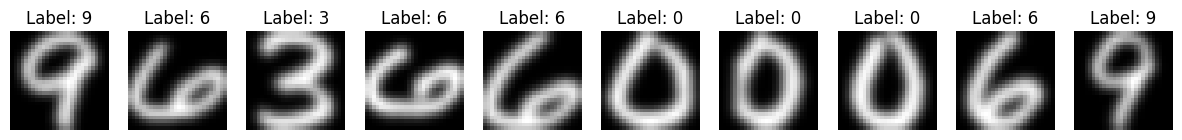

In [27]:
usps_train_loader, usps_test_loader = get_usps_loader()  # TODO: 记得补全Week14_utils_Question.py中的get_usps_loader()函数

def visualize_usps(loader, num_images=10):
    images, labels = next(iter(loader))
    plt.figure(figsize=(15, 2))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = images[i] * 0.3081 + 0.1307
        plt.imshow(img.squeeze().numpy(), cmap="gray")
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    plt.show()

print("Visualizing USPS Test Images:")
visualize_usps(usps_test_loader)

In [28]:
print("Evaluating original model on USPS...")
original_usps_acc = evaluate_dataloader(wm_model, usps_test_loader)
print(f"Original Model Acc on USPS: {original_usps_acc:.4f}")

Evaluating original model on USPS...


100%|██████████| 16/16 [00:00<00:00, 108.07it/s, test_acc=0.776]

Original Model Acc on USPS: 0.7758


In [29]:
wb_finetuned = finetune_on_usps(wm_model, usps_train_loader, epochs=5, lr=1e-3)

testset = torchvision.datasets.MNIST(root="./MNIST", train=False, download=True, transform=transforms.ToTensor())
test_loader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=True, drop_last=True)

target_b = whitebox_checkpoint["target_b"]
X_wm = whitebox_checkpoint["X_wm"]

wb_clean_acc = evaluate_dataloader(wb_finetuned, test_loader)
wb_usps_acc = evaluate_dataloader(wb_finetuned, usps_test_loader)
wb_match_rate = compute_match_rate(wb_finetuned, X_wm, target_b)

print("=== White-box Fine-tuning Attack (USPS) ===")
print(f"Original Model Acc on USPS: {original_usps_acc:.4f}")
print(f"Finetuned Acc on USPS:      {wb_usps_acc:.4f}")
print(f"Clean Acc (MNIST):          {wb_clean_acc:.4f}")
print(f"Match Rate:                 {wb_match_rate:.4f}")

[Fine-tune] Epoch 1/5, Loss: 0.1399
[Fine-tune] Epoch 2/5, Loss: 0.0394
[Fine-tune] Epoch 3/5, Loss: 0.0216
[Fine-tune] Epoch 4/5, Loss: 0.0161
[Fine-tune] Epoch 5/5, Loss: 0.0090


100%|██████████| 16/16 [00:00<00:00, 128.59it/s, test_acc=0.961]

=== White-box Fine-tuning Attack (USPS) ===
Original Model Acc on USPS: 0.7758
Finetuned Acc on USPS:      0.9611
Clean Acc (MNIST):          0.9086
Match Rate:                 1.0000


## 剪枝攻击评估流程

In [31]:
prune_ratios = [0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99]

wb_results = []
print("Running White-box Pruning Evaluation...")
for ratio in prune_ratios:
    model_p = prune(wm_model, ratio)
    clean_acc = evaluate_dataloader(model_p, test_loader)
    match_rate = compute_match_rate(model_p, X_wm, target_b)
    wb_results.append((ratio, clean_acc, match_rate))

print("\n=== White-box Watermark Robustness (Pruning) ===")
print("Ratio | Clean Acc | Match Rate")
print("-" * 40)
for ratio, clean_acc, match_rate in wb_results:
    print(f"{int(ratio * 100):>3}%   | {clean_acc:.4f}   | {match_rate:.4f}")

Running White-box Pruning Evaluation...


  0%|          | 0/78 [00:00<?, ?it/s, test_acc=0.977]

100%|██████████| 78/78 [00:00<00:00, 123.97it/s, test_acc=0.156]


=== White-box Watermark Robustness (Pruning) ===
Ratio | Clean Acc | Match Rate
----------------------------------------
 20%   | 0.9836   | 1.0000
 40%   | 0.9815   | 1.0000
 60%   | 0.9618   | 1.0000
 80%   | 0.8474   | 1.0000
 90%   | 0.4095   | 1.0000
 95%   | 0.3059   | 0.6250
 96%   | 0.3263   | 0.5000
 97%   | 0.2955   | 0.3750
 98%   | 0.2562   | 0.2500
 99%   | 0.1555   | 0.1250
